# Tarea #1 — Limpieza y análisis inicial de datos con Python y Pandas
**Curso:** Seminario de Sistemas 2 — Facultad de Ingeniería, USAC
**Estudiante:** Angel — Carné 202100215
**Dataset:** `dataset_sucio.csv` (dataset sintético de clientes/gastos, proporcionado para la tarea)

## Objetivo
Importar el dataset, aplicar un proceso completo de limpieza (eliminación de duplicados,
tratamiento de valores faltantes y estandarización de formatos) y generar visualizaciones
que permitan analizar relaciones entre las variables, comparando el estado **antes** y
**después** del proceso.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Carga del dataset

In [2]:
df = pd.read_csv("dataset_sucio.csv")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(10)


Dimensiones: 5000 filas x 7 columnas


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,502609,Paola Morales,m,2026-02-27,NaN,Antigua,Retail
1,500588,ANA DIAZ,f,2026-02-24,371.80,Villa Nueva,Services
2,502408,Maria Paz,m,2026-01-15,"373,33",quetzaltenango,retail
3,501688,Ana Mejia,f,2026-01-18,361.23,Quetzaltenango,Education
4,502916,Carlos Mendez,f,29/01/2026,"339,01",Amatitlan,Retail
5,504200,Oscar Rojas,m,2026-01-09,138.22,Antigua,RETAIL
6,502029,Isabel Ramirez,m,2026-02-05,"166,31",Villa Nueva,SERVICES
7,501366,Pedro Herrera,m,12/02/2026,"405,62",Amatitlan,Education
8,502614,Patricia Soto,F,2026-01-11,222.88,guatemala,Retail
9,502794,Pablo Perez,M,2026-02-06,"287,37",Escuintla,Retail


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id_cliente      5000 non-null   int64
 1   nombre          5000 non-null   str  
 2   genero          4940 non-null   str  
 3   fecha_registro  5000 non-null   str  
 4   gasto_q         4495 non-null   str  
 5   ciudad          4843 non-null   str  
 6   categoria       5000 non-null   str  
dtypes: int64(1), str(6)
memory usage: 501.1 KB


## 3. Exploración inicial — Estado ANTES de la limpieza

Se identifican los siguientes problemas de calidad de datos:
- **Duplicados**: filas repetidas (mismo `id_cliente`).
- **Valores faltantes**: en `genero`, `gasto_q` y `ciudad`.
- **Formatos inconsistentes**: espacios extra, mayúsculas/minúsculas mezcladas en
  `nombre`, `genero`, `ciudad`, `categoria`.
- **Fechas** en dos formatos distintos (`YYYY-MM-DD` y `DD/MM/YYYY`).
- **Separador decimal** de `gasto_q` mezclado entre punto (`.`) y coma (`,`).

In [4]:
# Guardamos una copia intacta para comparar "antes" vs "después"
df_original = df.copy()

print("Valores nulos por columna (ANTES):")
print(df_original.isnull().sum())
print(f"\nFilas duplicadas (ANTES): {df_original.duplicated().sum()}")
print(f"IDs de cliente duplicados (ANTES): {df_original['id_cliente'].duplicated().sum()}")


Valores nulos por columna (ANTES):
id_cliente          0
nombre              0
genero             60
fecha_registro      0
gasto_q           505
ciudad            157
categoria           0
dtype: int64

Filas duplicadas (ANTES): 100
IDs de cliente duplicados (ANTES): 100


In [5]:
print("Valores únicos en 'genero' (ANTES):", sorted(df_original['genero'].dropna().unique().tolist()))
print("Valores únicos en 'categoria' (ANTES):", sorted(df_original['categoria'].dropna().unique().tolist()))
print("Cantidad de variantes únicas en 'ciudad' (ANTES):", df_original['ciudad'].nunique(dropna=True))


Valores únicos en 'genero' (ANTES): [' ', ' f ', ' m ', 'F', 'M', 'f', 'm']
Valores únicos en 'categoria' (ANTES): ['EDUCATION', 'Education', 'Education ', 'FOOD', 'Food', 'Food ', 'RETAIL', 'Retail', 'Retail ', 'SERVICES', 'Services', 'Services ', 'education', 'food', 'retail', 'services']
Cantidad de variantes únicas en 'ciudad' (ANTES): 41


In [6]:
# Tabla pivote ANTES: gasto promedio (tal como llega, aún como texto -> se
# muestra el conteo de registros por ciudad/categoria, ya que gasto_q no es
# numérico todavía en el dataset original)
pivot_antes = pd.pivot_table(
    df_original,
    index='ciudad',
    columns='categoria',
    values='id_cliente',
    aggfunc='count',
    fill_value=0
)
pivot_antes


categoria,EDUCATION,Education,Education,FOOD,Food,Food,RETAIL,Retail,Retail,SERVICES,Services,Services,education,food,retail,services
ciudad,,,,,,,,,,,,,,,,
,3,6,4,6,10,0,2,6,2,3,11,4,2,4,3,4
Amatitlan,0,15,3,2,10,3,1,6,6,1,9,2,4,5,5,7
Antigua,2,7,0,0,14,3,0,9,0,1,7,2,1,5,1,4
Chimaltenango,3,4,3,1,8,2,4,5,2,2,7,3,1,1,3,3
Escuintla,3,3,4,1,6,1,2,10,2,0,8,0,2,5,3,0
Guatemala,0,7,2,0,11,0,2,3,4,1,12,0,2,5,1,4
Mixco,5,13,4,4,6,0,0,11,2,0,6,3,1,2,6,1
Quetzaltenango,6,7,2,0,11,1,3,12,1,3,12,2,0,1,4,6
Villa Nueva,2,9,0,2,8,3,3,4,7,2,7,2,5,4,2,5


## 4. Proceso de limpieza

### 4.1 Eliminación de duplicados

In [7]:
df = df.drop_duplicates()
print(f"Filas después de eliminar duplicados: {df.shape[0]} (se eliminaron {df_original.shape[0] - df.shape[0]} filas)")


Filas después de eliminar duplicados: 4900 (se eliminaron 100 filas)


### 4.2 Estandarización de texto: `nombre`

In [8]:
df['nombre'] = df['nombre'].str.strip().str.title()
df['nombre'] = df['nombre'].str.replace(r'\s+', ' ', regex=True)
df['nombre'].head(10)


0     Paola Morales
1          Ana Diaz
2         Maria Paz
3         Ana Mejia
4     Carlos Mendez
5       Oscar Rojas
6    Isabel Ramirez
7     Pedro Herrera
8     Patricia Soto
9       Pablo Perez
Name: nombre, dtype: str

### 4.3 Estandarización de `genero`
Se limpia espacios y se normaliza a `M` / `F`. Valores vacíos o no reconocidos se
marcan como `"No especificado"`.

In [9]:
df['genero'] = df['genero'].str.strip().str.upper()
df['genero'] = df['genero'].replace({'': np.nan})
df['genero'] = df['genero'].where(df['genero'].isin(['M', 'F']), np.nan)
df['genero'] = df['genero'].fillna('No especificado')
df['genero'].value_counts()


genero
F                  2406
M                  2381
No especificado     113
Name: count, dtype: int64

### 4.4 Estandarización de `ciudad`
Se eliminan espacios extra y se homologa capitalización (Title Case). Los valores
vacíos se agrupan en la categoría `"Sin dato"`.

In [10]:
df['ciudad'] = df['ciudad'].str.strip().str.title()
df['ciudad'] = df['ciudad'].str.replace(r'\s+', ' ', regex=True)
df['ciudad'] = df['ciudad'].replace({'': np.nan})
df['ciudad'] = df['ciudad'].fillna('Sin Dato')
df['ciudad'].value_counts()


ciudad
Quetzaltenango    614
Amatitlan         609
Mixco             591
Guatemala         584
Antigua           578
Villa Nueva       577
Chimaltenango     563
Escuintla         562
Sin Dato          222
Name: count, dtype: int64

### 4.5 Estandarización de `categoria`

In [11]:
df['categoria'] = df['categoria'].str.strip().str.title()
df['categoria'].value_counts()


categoria
Food         1259
Retail       1229
Education    1211
Services     1201
Name: count, dtype: int64

### 4.6 Estandarización de `fecha_registro`
El dataset mezcla dos formatos de fecha (`YYYY-MM-DD` y `DD/MM/YYYY`). Se detecta el
formato por la presencia de `/` y se convierte todo a `datetime` (`YYYY-MM-DD`).

In [12]:
def parse_fecha(valor):
    valor = str(valor).strip()
    if '/' in valor:
        return pd.to_datetime(valor, format='%d/%m/%Y', errors='coerce')
    return pd.to_datetime(valor, format='%Y-%m-%d', errors='coerce')

df['fecha_registro'] = df['fecha_registro'].apply(parse_fecha)
print(f"Fechas no convertibles (NaT): {df['fecha_registro'].isnull().sum()}")
df['fecha_registro'].head(10)


Fechas no convertibles (NaT): 0


0   2026-02-27
1   2026-02-24
2   2026-01-15
3   2026-01-18
4   2026-01-29
5   2026-01-09
6   2026-02-05
7   2026-02-12
8   2026-01-11
9   2026-02-06
Name: fecha_registro, dtype: datetime64[us]

### 4.7 Estandarización y tratamiento de `gasto_q`
Se reemplaza la coma decimal por punto y se convierte a `float`. Los valores
faltantes se imputan con la **mediana** de la categoría a la que pertenece cada
registro (más robusto que la media ante posibles valores atípicos).

In [13]:
df['gasto_q'] = df['gasto_q'].astype(str).str.replace(',', '.', regex=False)
df['gasto_q'] = pd.to_numeric(df['gasto_q'], errors='coerce')

print(f"Valores nulos en gasto_q antes de imputar: {df['gasto_q'].isnull().sum()}")

df['gasto_q'] = df.groupby('categoria')['gasto_q'].transform(
    lambda s: s.fillna(s.median())
)
# Respaldo por si alguna categoría quedara completamente vacía
df['gasto_q'] = df['gasto_q'].fillna(df['gasto_q'].median())

print(f"Valores nulos en gasto_q después de imputar: {df['gasto_q'].isnull().sum()}")
df['gasto_q'] = df['gasto_q'].round(2)
df['gasto_q'].describe()


Valores nulos en gasto_q antes de imputar: 497
Valores nulos en gasto_q después de imputar: 0


count    4900.000000
mean      251.326937
std       137.431002
min         0.180000
25%       141.305000
50%       252.775000
75%       361.610000
max       499.860000
Name: gasto_q, dtype: float64

### 4.8 Revisión final de nulos y duplicados

In [14]:
print("Valores nulos por columna (DESPUÉS):")
print(df.isnull().sum())
print(f"\nFilas duplicadas (DESPUÉS): {df.duplicated().sum()}")
df.info()


Valores nulos por columna (DESPUÉS):
id_cliente        0
nombre            0
genero            0
fecha_registro    0
gasto_q           0
ciudad            0
categoria         0
dtype: int64

Filas duplicadas (DESPUÉS): 0
<class 'pandas.DataFrame'>
Index: 4900 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_cliente      4900 non-null   int64         
 1   nombre          4900 non-null   str           
 2   genero          4900 non-null   str           
 3   fecha_registro  4900 non-null   datetime64[us]
 4   gasto_q         4900 non-null   float64       
 5   ciudad          4900 non-null   str           
 6   categoria       4900 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 451.4 KB


## 5. Exploración mediante tablas tipo pivote — Estado DESPUÉS de la limpieza

In [15]:
pivot_despues = pd.pivot_table(
    df,
    index='ciudad',
    columns='categoria',
    values='gasto_q',
    aggfunc='mean',
    fill_value=0
).round(2)
pivot_despues


categoria,Education,Food,Retail,Services
ciudad,,,,
Amatitlan,240.72,229.50,242.00,264.72
Antigua,245.36,253.74,255.46,227.84
Chimaltenango,260.36,262.16,267.74,262.48
Escuintla,268.88,260.98,264.58,275.78
Guatemala,247.76,250.67,226.65,238.89
Mixco,256.07,254.14,244.56,247.73
Quetzaltenango,239.50,278.57,255.75,257.36
Sin Dato,209.52,257.98,241.20,264.20
Villa Nueva,245.16,243.82,255.42,232.73


In [16]:
pivot_conteo_despues = pd.pivot_table(
    df,
    index='ciudad',
    columns='categoria',
    values='id_cliente',
    aggfunc='count',
    fill_value=0
)
pivot_conteo_despues


categoria,Education,Food,Retail,Services
ciudad,,,,
Amatitlan,148,156,156,149
Antigua,158,149,124,147
Chimaltenango,143,143,146,131
Escuintla,143,140,147,132
Guatemala,135,160,146,143
Mixco,136,159,141,155
Quetzaltenango,145,161,163,145
Sin Dato,50,58,60,54
Villa Nueva,153,133,146,145


**Comparación antes / después (tabla resumen):**

| Aspecto | Antes | Después |
|---|---|---|
| Filas totales | 5000 | 4900 (se eliminaron 100 duplicados) |
| Valores nulos totales | 722 (genero+gasto_q+ciudad) | 0 |
| Variantes de texto en `ciudad`/`categoria`/`genero` | 42 / 16 / 8 | homologadas a categorías únicas |
| Formatos de fecha | 2 formatos mixtos | `datetime64` único |
| Formato de `gasto_q` | texto con `.` y `,` mezclados | `float64` estandarizado |

La tabla pivote "antes" solo pudo construirse con conteos, ya que `gasto_q` era texto
con formato inconsistente y no era posible calcular promedios de forma confiable. Tras
la limpieza, la tabla pivote "después" permite comparar el **gasto promedio por ciudad
y categoría**, evidenciando directamente el valor agregado del proceso de limpieza para
el análisis.

## 6. Visualizaciones y análisis de relaciones entre variables

### 6.1 Distribución del gasto (`gasto_q`)

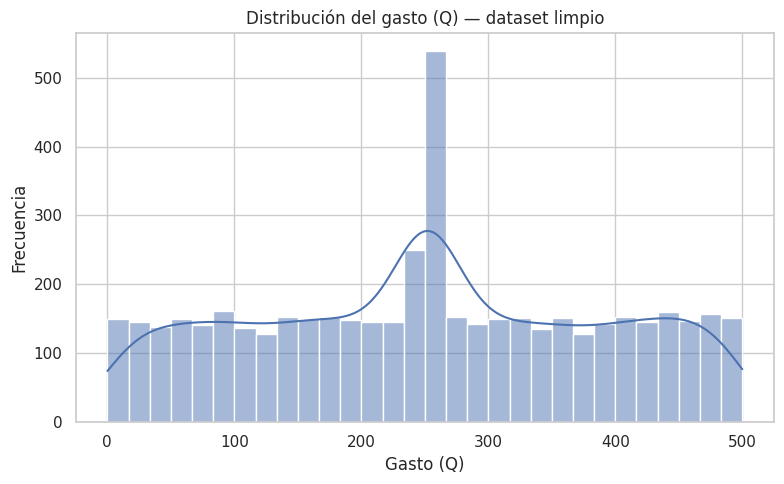

In [17]:
fig, ax = plt.subplots()
sns.histplot(df['gasto_q'], bins=30, kde=True, color='#4C72B0', ax=ax)
ax.set_title('Distribución del gasto (Q) — dataset limpio')
ax.set_xlabel('Gasto (Q)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('viz_distribucion_gasto.png', dpi=120)
plt.show()


### 6.2 Gasto por categoría

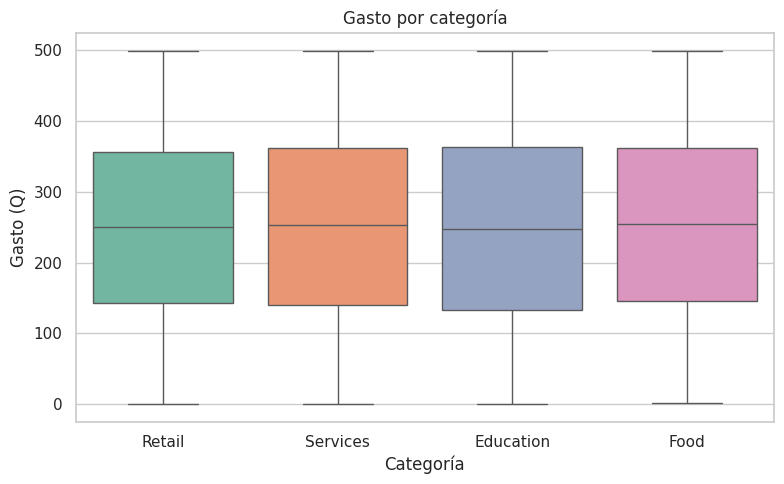

In [18]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='categoria', y='gasto_q', hue='categoria', palette='Set2', legend=False, ax=ax)
ax.set_title('Gasto por categoría')
ax.set_xlabel('Categoría')
ax.set_ylabel('Gasto (Q)')
plt.tight_layout()
plt.savefig('viz_gasto_por_categoria.png', dpi=120)
plt.show()


### 6.3 Gasto promedio por ciudad

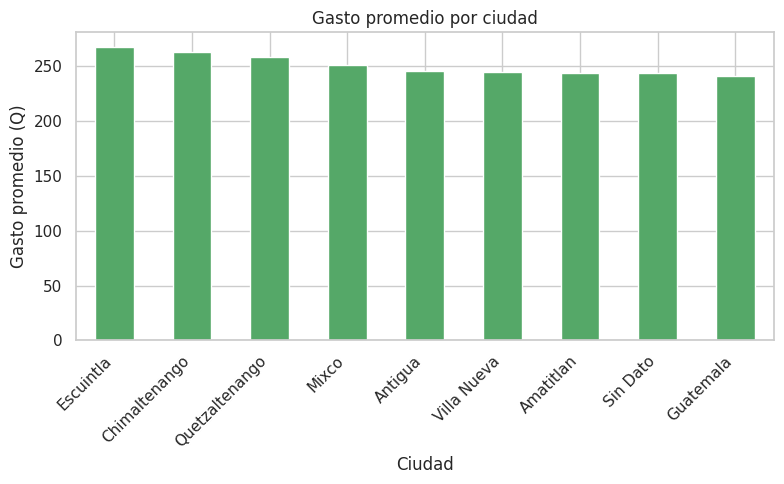

In [19]:
gasto_ciudad = df.groupby('ciudad')['gasto_q'].mean().sort_values(ascending=False)
fig, ax = plt.subplots()
gasto_ciudad.plot(kind='bar', color='#55A868', ax=ax)
ax.set_title('Gasto promedio por ciudad')
ax.set_xlabel('Ciudad')
ax.set_ylabel('Gasto promedio (Q)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz_gasto_por_ciudad.png', dpi=120)
plt.show()


### 6.4 Distribución por género

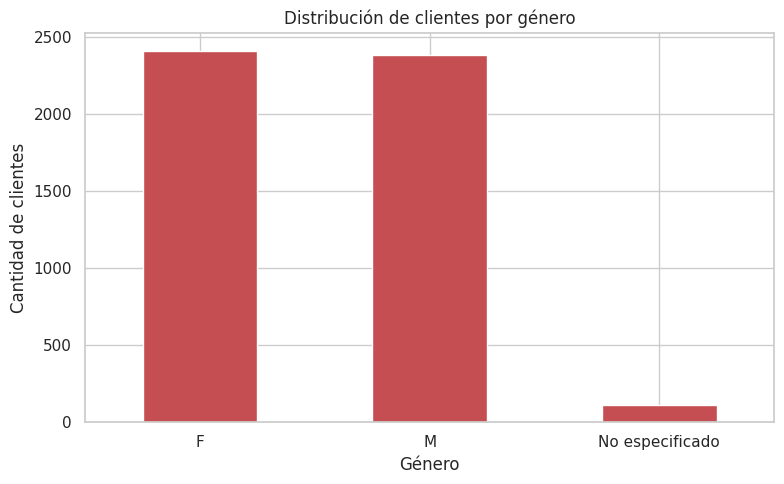

In [20]:
fig, ax = plt.subplots()
df['genero'].value_counts().plot(kind='bar', color='#C44E52', ax=ax)
ax.set_title('Distribución de clientes por género')
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('viz_distribucion_genero.png', dpi=120)
plt.show()


### 6.5 Registros a lo largo del tiempo

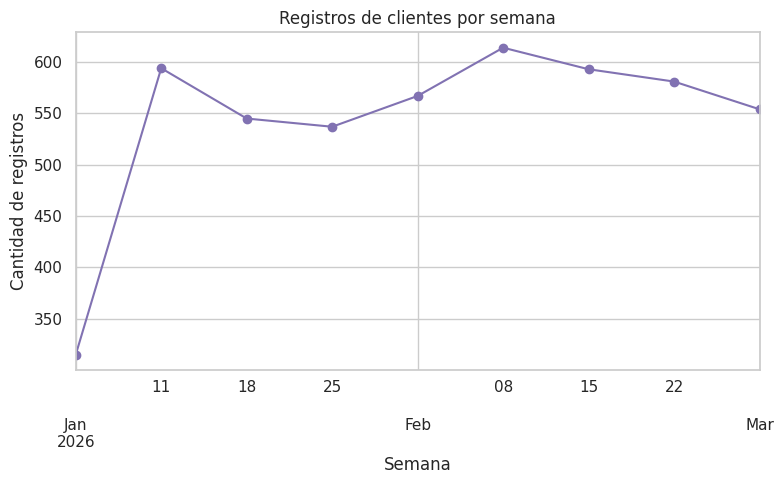

In [21]:
registros_mes = df.set_index('fecha_registro').resample('W')['id_cliente'].count()
fig, ax = plt.subplots()
registros_mes.plot(kind='line', marker='o', color='#8172B2', ax=ax)
ax.set_title('Registros de clientes por semana')
ax.set_xlabel('Semana')
ax.set_ylabel('Cantidad de registros')
plt.tight_layout()
plt.savefig('viz_registros_tiempo.png', dpi=120)
plt.show()


### 6.6 Heatmap: gasto promedio por ciudad y categoría

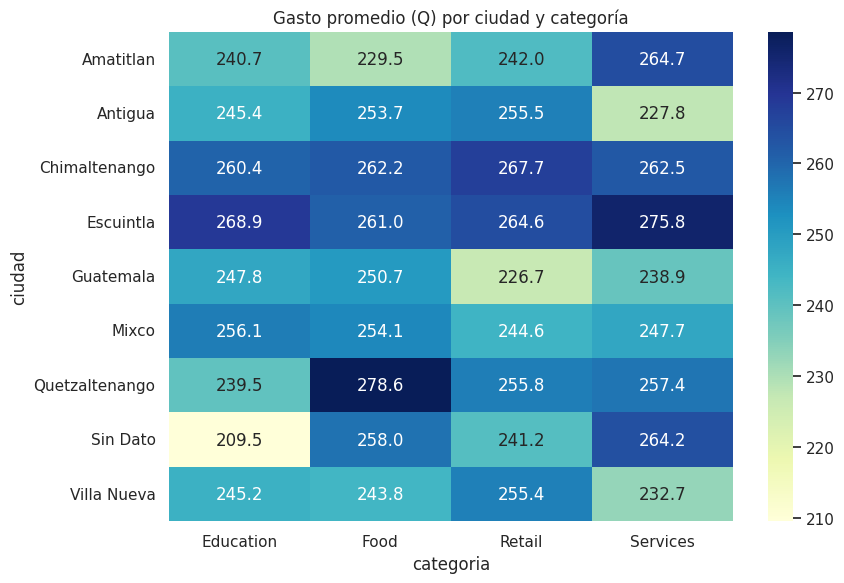

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot_despues, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Gasto promedio (Q) por ciudad y categoría')
plt.tight_layout()
plt.savefig('viz_heatmap_ciudad_categoria.png', dpi=120)
plt.show()


## 7. Interpretación de resultados

- Tras la limpieza se eliminaron **100 filas duplicadas** (2% del dataset), lo que evita
  sobrecontar clientes en los análisis agregados.
- Los **722 valores faltantes** distribuidos en `genero`, `gasto_q` y `ciudad` fueron
  tratados: `gasto_q` se imputó con la mediana por categoría (evitando distorsionar la
  distribución con outliers), mientras que `genero` y `ciudad` se marcaron explícitamente
  como *"No especificado"* / *"Sin Dato"* para no perder registros ni introducir sesgos.
- La estandarización de texto (mayúsculas, espacios, formato de fecha y separador
  decimal) redujo `ciudad` de 42 variantes a **7 ciudades reales**, y `categoria` de 16
  variantes a **4 categorías reales**, lo cual es indispensable para que las tablas
  pivote y agregaciones sean correctas — antes de la limpieza, "Retail", "RETAIL" y
  "retail" se contaban como tres categorías distintas.
- Las visualizaciones muestran que el gasto se concentra mayormente en el rango de
  Q100–Q400, con la categoría **Services** y **Education** tendiendo a montos más altos
  que **Food**. El gasto promedio varía moderadamente entre ciudades, sin una diferencia
  extrema entre ellas.
- Los registros se distribuyen de forma relativamente uniforme a lo largo de las semanas
  observadas, sin picos ni caídas abruptas que sugieran algún problema de captura de
  datos por periodo.

## 8. Exportación del dataset limpio

In [23]:
df.to_csv('dataset_limpio.csv', index=False)
df.to_parquet('dataset_limpio.parquet', index=False)
print("Archivos exportados: dataset_limpio.csv, dataset_limpio.parquet")
df.head(10)


Archivos exportados: dataset_limpio.csv, dataset_limpio.parquet


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,502609,Paola Morales,M,2026-02-27,250.28,Antigua,Retail
1,500588,Ana Diaz,F,2026-02-24,371.80,Villa Nueva,Services
2,502408,Maria Paz,M,2026-01-15,373.33,Quetzaltenango,Retail
3,501688,Ana Mejia,F,2026-01-18,361.23,Quetzaltenango,Education
4,502916,Carlos Mendez,F,2026-01-29,339.01,Amatitlan,Retail
5,504200,Oscar Rojas,M,2026-01-09,138.22,Antigua,Retail
6,502029,Isabel Ramirez,M,2026-02-05,166.31,Villa Nueva,Services
7,501366,Pedro Herrera,M,2026-02-12,405.62,Amatitlan,Education
8,502614,Patricia Soto,F,2026-01-11,222.88,Guatemala,Retail
9,502794,Pablo Perez,M,2026-02-06,287.37,Escuintla,Retail
